<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Aprendizaje%20Supervisado/Practico%201/AS_2026_Entregable_Mariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

por: Mariano Baggini

---
## Kaggle Competition: Clasificación de imágenes de rostros con o sin barbijos

**Objetivos especificos**:

- Explorar los datos y aprender de ellos.
- Probar diferentes modelos y ver cuáles ajustan mejor dado los datos.
- Para esta competencia se elige como métrica el **balanced_accuracy_score**. Discutir, analizar y justificar porque es necesaria está métrica para este problema.
- **Obtener una métrica mejor que la que se presenta en este ejemplo.**
- Tratar de obtener un score lo más alto posible!
- Discutir la elección de modelo.

NOTA: El análisis exploratorio y el preprocesamiento de los datos queda a libertad de cada grupo y no deben quedarse con este simple ejemplo.

In [ ]:
# Librerias usadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report, precision_score, accuracy_score, balanced_accuracy_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## 1. Carga de datos


### 1.1 Datos de entrenamiento

Cargamos los datos de entrenamiento que vamos a utilizar para generar nuestro modelo.

In [ ]:
train_url = 'https://raw.github.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv'
train_data = pd.read_csv(train_url, delimiter=';')

In [ ]:
train_df = train_data.copy()
train_df.head(2)

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,ccb,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,ccb,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528


In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Columns: 438 entries, id to 198
dtypes: float64(434), int64(3), str(1)
memory usage: 6.3 MB


La columna `clase` es la columna que debemos predecir. En el dataset de Test esta columna tiene valores nulos.

### 1.2 Datos de testeo

Cargamos los datos de test. Estos datos son los que van a utilizar para predecir si las personas tienen barbijos colocados en el rostro y generar alrchivo `submision.csv` para utilizar en la competencia de Kaggle.

In [ ]:
test_url = 'https://raw.github.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv'
test_data = pd.read_csv(test_url, delimiter=';')

In [ ]:
test_df = test_data.copy()
test_df.head(2)

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,ccb,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,ccb,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528


In [ ]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Columns: 438 entries, id to 198
dtypes: float64(434), int64(3), str(1)
memory usage: 6.3 MB


## 2. Analisis de los datos

### 2.1 Estudio de desbalance

Veamos de que manera se distribuyen los datos en los valores del feature objetivo: `clase`.

In [ ]:
train_df.describe()

,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
count,1884.000000,1884.000000,1884.00000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,...,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000
mean,942.500000,101.909236,133.47983,114.109534,0.168035,0.400830,1.690452,0.296696,0.445435,0.442737,...,0.066285,0.171946,0.215352,0.416790,0.085017,0.320012,0.318657,0.693318,0.223473,0.250213
std,544.008272,91.933372,119.15816,30.696614,0.126249,0.273933,1.219991,0.213530,0.406341,0.284700,...,0.069526,0.179459,0.209379,0.278408,0.086755,0.221458,0.231352,0.457887,0.116369,0.161713
min,1.000000,11.000000,12.00000,40.301282,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000246,0.000000,0.000648,0.000000,0.001931,0.007359,0.000000
25%,471.750000,48.750000,59.00000,92.309942,0.075003,0.199049,0.547147,0.135446,0.115591,0.237259,...,0.015967,0.058051,0.064764,0.194096,0.023932,0.152957,0.141901,0.331458,0.133532,0.129353
50%,942.500000,71.000000,88.00000,109.841245,0.143056,0.336917,1.631053,0.251868,0.342227,0.381312,...,0.045157,0.119384,0.147675,0.360841,0.057883,0.271596,0.274714,0.618690,0.214287,0.219952
75%,1413.250000,120.000000,167.00000,134.545488,0.234480,0.541367,2.653032,0.400949,0.644068,0.569638,...,0.095316,0.217514,0.307282,0.593489,0.117845,0.435103,0.450637,0.946997,0.296023,0.336383
max,1884.000000,1296.000000,1070.00000,202.392985,0.991374,1.821444,5.263674,1.397370,2.541877,2.500119,...,0.538534,1.363758,1.493638,1.545518,0.859438,1.943598,1.753040,3.450385,0.627220,1.135739


In [ ]:
# Limpieza elemental
train_df = train_df.drop_duplicates()
train_df['clase'].info()

<class 'pandas.Series'>
RangeIndex: 1884 entries, 0 to 1883
Series name: clase
Non-Null Count  Dtype
--------------  -----
1884 non-null   str  
dtypes: str(1)
memory usage: 14.8 KB


<Axes: xlabel='clase'>

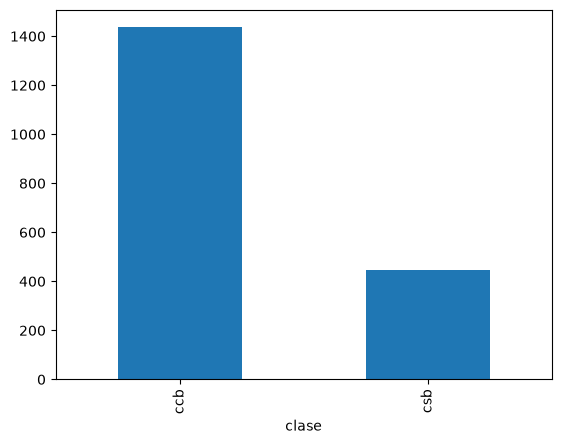

In [ ]:
# Estudio de desbalance
train_df.groupby("clase").clase.value_counts().plot(kind='bar')

In [ ]:
# Distribucion de datos
conteo = train_df['clase'].value_counts()
porcentaje = (train_df['clase'].value_counts(normalize='True')*100).round(2)

tabla_distribucion = pd.DataFrame({
    'Frecuencia':conteo,
    'Porcentaje (%)':porcentaje
})

tabla_distribucion

,Frecuencia,Porcentaje (%)
clase,,
ccb,1436,76.22
csb,448,23.78


Se observa un claro desbalance entre clases. Hay un 76.22% de imagenes con barbijo frente a un 23.78 sin este.

### 2.2 Codificacion de `clase`

In [ ]:
# Mapeo de valores. Valido porque estan acotadas
mapeo_directo = {'ccb': 1, 'csb': 0}
train_df['clase'] = train_df['clase'].map(mapeo_directo)

# Verificacion
train_df['clase'].value_counts()

clase
1    1436
0     448
Name: count, dtype: int64

### 2.3 Preparacion de datasets

In [ ]:
# Aislo la variable objetivo: clase
y = train_df.clase
X = train_df.drop('clase',axis=1)
X.head(3)

,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,0.141102,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,0.213251,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528
2,3,123,167,93.290398,0.139690,0.759909,0.081340,0.325830,0.018619,0.170640,...,0.021488,0.350511,0.165781,0.114810,0.154125,0.193874,0.393903,0.170703,0.099427,0.344505


In [ ]:
# Separacion de la columna con los Id de las imágenes en una sola variable:
imagenID = X.id
X.drop('id',axis=1,inplace=True)

In [ ]:
# Estandarizado de variables:
x_names = X.columns
X = StandardScaler().fit_transform(X)
X = pd.DataFrame(X, columns=x_names)
X.head(3)

,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,1843,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,0.175073,0.281383,0.387523,0.026208,-0.532828,0.032379,2.697306,0.491393,-1.059764,-0.720381,...,-0.950096,-0.505110,0.843567,-0.608877,-0.598472,0.338203,-0.493066,2.129262,-1.467671,0.321267
1,2.002968,2.203709,1.251718,0.034641,-0.669883,0.992496,0.583859,-0.429723,-0.806275,-0.447428,...,-0.147339,-0.629339,-0.440919,0.165945,-0.552029,1.530114,-0.631851,-0.406197,0.436875,2.463745
2,0.229474,0.281383,-0.678403,-0.224577,1.311175,-1.319304,0.136473,-1.050667,-0.955986,-1.186158,...,-0.644487,0.995278,-0.236813,-1.084954,0.796811,-0.569734,0.325329,-1.141667,-1.066261,0.583238


Con esto, separamos los datasets de entrenamiento y testeo:

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 0)

In [ ]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 1507 entries, 1038 to 684
Columns: 436 entries, bb_width to 198
dtypes: float64(436)
memory usage: 5.0 MB


In [ ]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 377 entries, 883 to 518
Columns: 436 entries, bb_width to 198
dtypes: float64(436)
memory usage: 1.3 MB


## 3. Planteo de modelos

In [ ]:
seed = 42

clfs = [
    DecisionTreeClassifier(random_state=seed, class_weight='balanced'),
    SVC(random_state=seed, class_weight='balanced'),
    RandomForestClassifier(random_state=seed, class_weight='balanced')
]

names = ['Árbol de Decisión', 'SVM', 'Random Forest']

# Diccionario para almacenar métricas de forma trazable
resultados = []
trained_models = {}

In [ ]:
for clf, name in zip(clfs, names):
    # Entrenar
    clf.fit(x_train, y_train)
    trained_models[name] = clf  # Guardamos el modelo por su nombre

    # Predicciones
    train_preds = clf.predict(x_train)
    test_preds = clf.predict(x_test)

    # Calcular métricas (Añadimos F1-Score, vital para desbalanceo)
    metricas = {
        'Modelo': name,
        'Recall Train': recall_score(y_train, train_preds),
        'Recall Test': recall_score(y_test, test_preds),
        'Precision Test': precision_score(y_test, test_preds),
        'Balanced Acc Test': balanced_accuracy_score(y_test, test_preds),
        'F1-Score Test': f1_score(y_test, test_preds)
    }

    resultados.append(metricas)

In [ ]:
# 3. Convertimos a DataFrame para comparar de forma óptima
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
# Multiplicamos por 100 y redondeamos para que sea legible
df_resultados = (df_resultados * 100).round(2)

print(df_resultados)

                   Recall Train  Recall Test  Precision Test  \
Modelo                                                         
Árbol de Decisión        100.00        97.13           96.79   
SVM                       99.65       100.00           98.94   
Random Forest            100.00        99.28           96.85   

                   Balanced Acc Test  F1-Score Test  
Modelo                                               
Árbol de Decisión              93.97          96.96  
SVM                            98.47          99.47  
Random Forest                  95.05          98.05  


Con lo anterior, vemos que el modelo con mejor respuesta en el Recall, ponderando train y test, es el random forest. Procedemos a optimizar su implementacion:

In [ ]:
# 1. Entrenamos un bosque rápido para evaluar la importancia de las variables
# Usamos class_weight='balanced_subsample' que es ideal para bosques con desbalanceo
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf_selector.fit(x_train, y_train)

# 2. Extraemos las importancias y las ordenamos
importancias = rf_selector.feature_importances_
indices_ordenados = np.argsort(importancias)[::-1]

# 3. Nos quedamos, por ejemplo, con el TOP 50 de variables más importantes
# (Puedes ajustar este número o usar un umbral de corte)
K_MEJORES = 50
features_seleccionadas = x_train.columns[indices_ordenados[:K_MEJORES]]

# 4. Reducimos nuestras matrices de entrenamiento y prueba
x_train_reducido = x_train[features_seleccionadas]
x_test_reducido = x_test[features_seleccionadas]

print(f"Matriz original: {x_train.shape} -> Nueva matriz reducida: {x_train_reducido.shape}")

Matriz original: (1507, 436) -> Nueva matriz reducida: (1507, 50)


In [ ]:
# Definicion de grilla
param_grid_rf = {
    'n_estimators': [100, 200, 300],          # Número de árboles en el bosque
    'max_depth': [5, 10, 15, None],           # Controla el sobreajuste limitando la profundidad
    'min_samples_split': [2, 5, 10],          # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],            # Mínimo de muestras que debe tener una hoja
    'class_weight': ['balanced', 'balanced_subsample'] # Vital para tus clases desbalanceadas
}

# Configuración del GridSearch enfocado en RECALL
svm_base = RandomForestClassifier(random_state=42)
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_rf,
    scoring='recall',                         # Buscamos exprimir el Recall
    cv=cv_estrategia,
    n_jobs=-1,
    verbose=1
)

# Entrenamos con la matriz reducida del Paso 1
grid_search_rf.fit(x_train_reducido, y_train)

print("Mejor Recall obtenido en CV: %.2f%%" % (grid_search_rf.best_score_ * 100))
print("Mejores parámetros para Random Forest:", grid_search_rf.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejor Recall obtenido en CV: 99.31%
Mejores parámetros para Random Forest: {'class_weight': 'balanced_subsample', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Probamos tambien con SVM ya que el recall de test fue ligeramente superior al anterior, aunque su desempeño en entrenamiento no lo refleja univocamente:

In [ ]:
# Seleccion de filas relevantes
selector = SelectKBest(score_func=f_classif, k=K_MEJORES)

# 3. Ajustamos el selector con los datos de entrenamiento escalados
x_train_reducido = selector.fit_transform(x_train_scaled, y_train)
x_test_reducido = selector.transform(x_test_scaled)

# Recuperamos los nombres de las columnas seleccionadas para mantener la trazabilidad
features_seleccionadas = selector.get_feature_names_out()

print(f"Matriz original: {x_train.shape} -> Nueva matriz reducida y escalada: {x_train_reducido.shape}")

NameError: name 'SelectKBest' is not defined

In [ ]:
param_grid_svm = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'class_weight': ['balanced'] # Penalización alta para la clase minoritaria
    },
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'class_weight': ['balanced']
    }
]

In [ ]:
# Configuración del GridSearch enfocado en RECALL
svm_base = SVC(random_state=42)
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    scoring='recall', # Tu métrica objetivo principal
    cv=cv_estrategia,
    n_jobs=-1,
    verbose=1
)

# Entrenamos con la matriz reducida y escalada del Paso 1
grid_search_svm.fit(x_train_reducido, y_train)

print("Mejor Recall obtenido en CV: %.2f%%" % (grid_search_svm.best_score_ * 100))
print("Mejores parámetros para SVM:", grid_search_svm.best_params_)

## Generar la salida para entregar